<a href="https://colab.research.google.com/github/LucaWata/Calculo_Numerico/blob/main/Atividade_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aluno(a): Luca Ryuichi Kasai Watanabe | Turma: IB | Data: 26/08/2026

# Bibliotecas

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parte A - Truncamento e Arredondamento

### Funções e Valores

In [11]:
def truncar(x, n):
  fator = 10 ** n
  return np.trunc(x * fator) / fator

def erro_absoluto(x, aproximacao):
  return abs(x - aproximacao)

def erro_relativo(x, aproximacao):
  return abs(x - aproximacao) / abs(x)

def erro_percentual(x, aproximacao):
  return 100 * erro_relativo(x, aproximacao)

valores = [3.14159265, 98.76543, 0.00498765]

### Calcular a aproximacao por truncamento e por arredondamento e colocar na tabela

In [12]:
resultados = []

for x in valores:
  for n in range(5):

    trunc = truncar(x, n)

    Ea_trunc = erro_absoluto(x, trunc)
    Er_trunc = erro_relativo(x, trunc)
    Ep_trunc = erro_percentual(x, trunc)

    arred = round(x, n)

    Ea_arred = erro_absoluto(x, arred)
    Er_arred = erro_relativo(x, arred)
    Ep_arred = erro_percentual(x, arred)

    resultados.append([
      x,
      n,
      trunc,
      arred,
      Ea_trunc,
      Er_trunc,
      Ep_trunc,
      Ea_arred,
      Er_arred,
      Ep_arred
    ])

tabela = pd.DataFrame(resultados, columns = [
  "x",
  "n",
  "Truncamento",
  "Arredondamento",
  "Ea (Truncamento)",
  "Er (Truncamento)",
  "Ep (Truncamento)",
  "Ea (Arredondamento)",
  "Er (Arredondamento)",
  "Ep (Arredondamento)"
])

display(tabela)

,x,n,Truncamento,Arredondamento,Ea (Truncamento),Er (Truncamento),Ep (Truncamento),Ea (Arredondamento),Er (Arredondamento),Ep (Arredondamento)
0,3.141593,0,3.0000,3.0000,0.141593,4.507034e-02,4.507034,0.141593,4.507034e-02,4.507034
1,3.141593,1,3.1000,3.1000,0.041593,1.323935e-02,1.323935,0.041593,1.323935e-02,1.323935
2,3.141593,2,3.1400,3.1400,0.001593,5.069562e-04,0.050696,0.001593,5.069562e-04,0.050696
3,3.141593,3,3.1410,3.1420,0.000593,1.886464e-04,0.018865,0.000407,1.296635e-04,0.012966
4,3.141593,4,3.1415,3.1416,0.000093,2.949141e-05,0.002949,0.000007,2.339578e-06,0.000234
5,98.765430,0,98.0000,99.0000,0.765430,7.749979e-03,0.774998,0.234570,2.375021e-03,0.237502
6,98.765430,1,98.7000,98.8000,0.065430,6.624788e-04,0.066248,0.034570,3.500213e-04,0.035002
7,98.765430,2,98.7600,98.7700,0.005430,5.497875e-05,0.005498,0.004570,4.627125e-05,0.004627
8,98.765430,3,98.7650,98.7650,0.000430,4.353750e-06,0.000435,0.000430,4.353750e-06,0.000435
9,98.765430,4,98.7654,98.7654,0.000030,3.037500e-07,0.000030,0.000030,3.037500e-07,0.000030


###Inserindo os dados obtidos em um gráfico

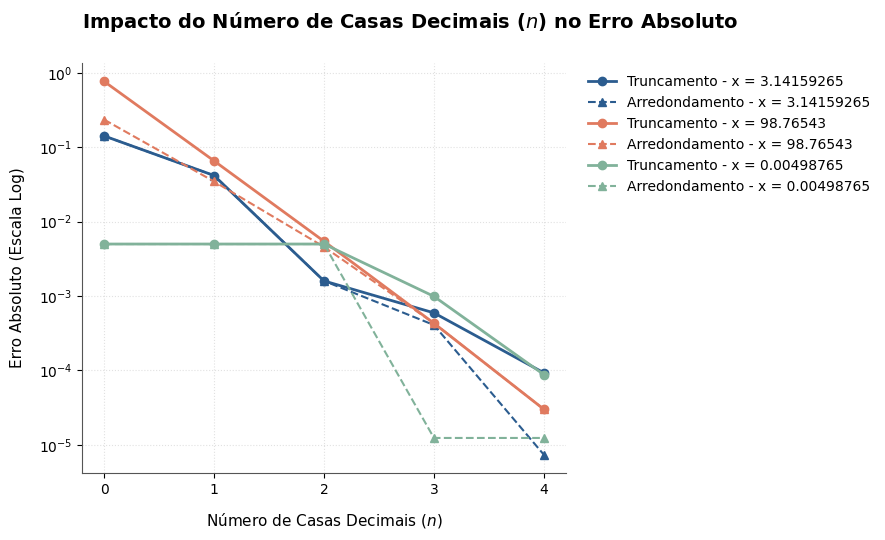

In [13]:
cores = {
  3.14159265: "#2B5C8F",
  98.76543: "#E07A5F",
  0.00498765: "#81B29A"
}
cor_texto = "#000000"
cor_grade = "#D5D5D5"

fig, ax = plt.subplots(figsize = (9, 5.5), dpi = 100, facecolor = "white")

for x in valores:
  dados_x = tabela[tabela["x"] == x]
  cor_atual = cores[x]

  plt.plot(
    dados_x["n"],
    dados_x["Ea (Truncamento)"],
    marker = "o",
    markersize = 6,
    linewidth = 2,
    color = cor_atual,
    label = f"Truncamento - x = {x}"
  )

  plt.plot(
    dados_x["n"],
    dados_x["Ea (Arredondamento)"],
    marker = "^",
    markersize = 6,
    linewidth = 1.5,
    linestyle = "--",
    color = cor_atual,
    label = f"Arredondamento - x = {x}"
  )


ax.set_yscale("symlog", linthresh = 1e-6)

ax.spines["top"].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

ax.set_xticks(range(5))

ax.grid(True,
        which = "both",
        axis = 'both',
        linestyle = ':',
        alpha = 0.7,
        color = cor_grade
    )

ax.set_title("Impacto do Número de Casas Decimais ($n$) no Erro Absoluto",
             fontsize = 14,
             fontweight = 'bold',
             pad = 25,
             color = "#000000",
             loc = 'left'
             )

ax.set_xlabel("Número de Casas Decimais ($n$)",
              fontsize = 11,
              labelpad = 10,
              color = "#000000"
             )

ax.set_ylabel("Erro Absoluto (Escala Log)",
              fontsize = 11,
              labelpad = 10,
              color = "#000000"
              )

ax.tick_params(axis = 'both',
               colors = "#000000",
               labelsize = 10
               )

ax.legend(bbox_to_anchor=(1.02, 1),
          loc = 'upper left',
          frameon = False,
          fontsize = 10,
          labelcolor = "#000000"
          )

plt.tight_layout()
plt.show()

### Arredondar sempre gera erro menor ou igual ao truncamento? Justifique com os resultados.

Arredondar vai gerar um erro igual ou com uma diferença mínima ao do truncamento. Essa pequena diferença é vista quando o número de casas decimais é maior ou igual a 3. Para o número de casas de 0 a 2 essa diferença não é perceptível

# Parte B - Medidas de pressão arterial

## B.1 - Representação das medidas

### Dados fornecidos pelo exercício

In [14]:
pressao = np.array([
    121.7,
    120.4,
    122.1,
    119.8,
    121.2,
    120.9,
    122.4,
    121.0,
    120.2,
    121.5
])

### Criando as 4 séries pedidas

In [15]:
pressao_original = pressao

pressao_arred_int = np.round(pressao).astype(int)

pressao_trunc_int = np.trunc(pressao).astype(int)

pressao_arred_1 = np.round(pressao, 1)

### Inserindo os dados obtidos das 4 séries em uma tabela

In [16]:
series = pd.DataFrame({
    "Original": pressao_original,
    "Arredondado (int)": pressao_arred_int,
    "Truncado (int)": pressao_trunc_int,
    "Arredondado (1 casa decimal)": pressao_arred_1
})

display(series)

,Original,Arredondado (int),Truncado (int),Arredondado (1 casa decimal)
0,121.7,122,121,121.7
1,120.4,120,120,120.4
2,122.1,122,122,122.1
3,119.8,120,119,119.8
4,121.2,121,121,121.2
5,120.9,121,120,120.9
6,122.4,122,122,122.4
7,121.0,121,121,121.0
8,120.2,120,120,120.2
9,121.5,122,121,121.5


### Calculando a média de referência

In [17]:
media_referencia = np.mean(pressao_original)

print(f"Media de referencia: {media_referencia:f} mmHg")

Media de referencia: 121.120000 mmHg


### Calculando a média, mínimo, máximo, amplitude e desvio-padrão das 4 séries

In [18]:
ddof = 1 #desvio padrão amostral

dados_series = {
    "Original": pressao_original,
    "Arredondada (inteiro)": pressao_arred_int,
    "Truncada (inteiro)": pressao_trunc_int,
    "Arredondada (1 casa decimal)": pressao_arred_1
}

estatisticas = []

for nome, dados in dados_series.items():

    media = np.mean(dados)
    minimo = np.min(dados)
    maximo = np.max(dados)
    amplitude = maximo - minimo
    desvio_padrao = np.std(dados, ddof=ddof)

    estatisticas.append([
        nome,
        media,
        minimo,
        maximo,
        amplitude,
        desvio_padrao
    ])

tabela_estatisticas = pd.DataFrame(estatisticas, columns=[
    "Série",
    "Média (mmHg)",
    "Mínimo (mmHg)",
    "Máximo (mmHg)",
    "Amplitude (mmHg)",
    "Desvio Padrão Amostral (mmHg)"
])

display(tabela_estatisticas)

,Série,Média (mmHg),Mínimo (mmHg),Máximo (mmHg),Amplitude (mmHg),Desvio Padrão Amostral (mmHg)
0,Original,121.12,119.8,122.4,2.6,0.833733
1,Arredondada (inteiro),121.10,120.0,122.0,2.0,0.875595
2,Truncada (inteiro),120.70,119.0,122.0,3.0,0.948683
3,Arredondada (1 casa decimal),121.12,119.8,122.4,2.6,0.833733


### Calculando os três erros das médias

In [19]:
erros_medias = []

for nome, dados in dados_series.items():

    media = np.mean(dados)

    Ea = erro_absoluto(media_referencia, media)
    Er = erro_relativo(media_referencia, media)
    Ep = erro_percentual(media_referencia, media)

    erros_medias.append([
        nome,
        media,
        Ea,
        Er,
        Ep
    ])

tabela_erros = pd.DataFrame(
    erros_medias,
    columns = [
        "Série",
        "Média (mmHg)",
        "Erro Absoluto (mmHg)",
        "Erro Relativo",
        "Erro Percentual (%)"
    ]
)

display(tabela_erros)

,Série,Média (mmHg),Erro Absoluto (mmHg),Erro Relativo,Erro Percentual (%)
0,Original,121.12,0.00,0.000000,0.000000
1,Arredondada (inteiro),121.10,0.02,0.000165,0.016513
2,Truncada (inteiro),120.70,0.42,0.003468,0.346764
3,Arredondada (1 casa decimal),121.12,0.00,0.000000,0.000000


## B.2 - Gráficos obrigatórios

### Gráfico das dez medições, mostrando as 4 séries

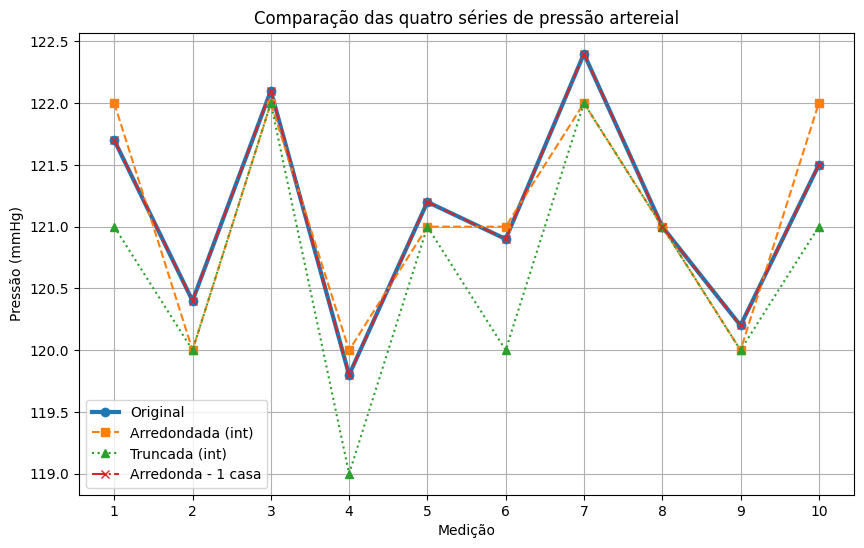

In [25]:
plt.figure(figsize = (10, 6))

x = np.arange(1, 11)

plt.plot(x, pressao_original, marker="o", linewidth = 3, label="Original")
plt.plot(x, pressao_arred_int, marker="s", linestyle = "--", label="Arredondada (int)")
plt.plot(x, pressao_trunc_int, marker="^", linestyle = ":", label="Truncada (int)")
plt.plot(x, pressao_arred_1, marker="x", linestyle = "-.", label="Arredonda - 1 casa")

plt.xlabel("Medição")
plt.ylabel("Pressão (mmHg)")
plt.title("Comparação das quatro séries de pressão artereial")

plt.xticks(x)
plt.grid(True)
plt.legend()

plt.show()

### Gráfico de barras dos erros absolutos das médias

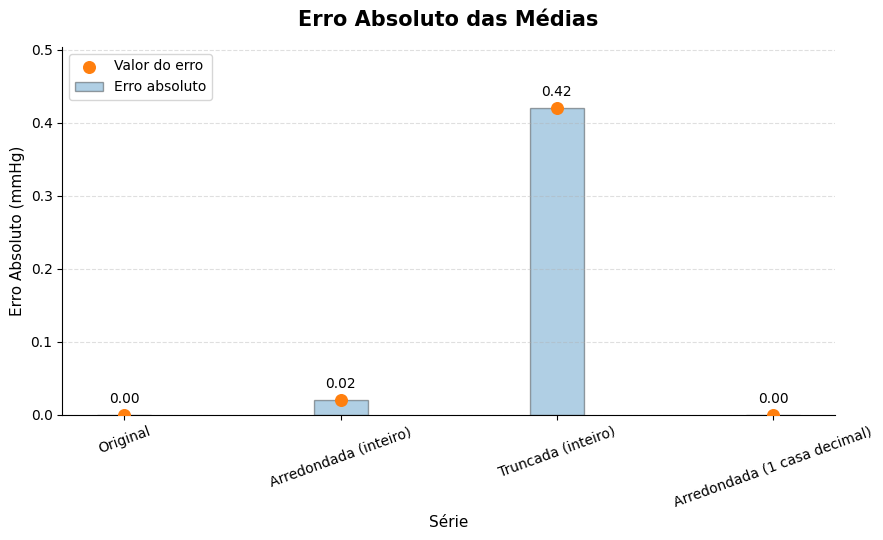

In [43]:
plt.figure(figsize=(9, 5.5))

valores = tabela_erros["Erro Absoluto (mmHg)"]

barras = plt.bar(
    tabela_erros["Série"],
    valores,
    width = 0.25,
    alpha = 0.35,
    edgecolor = "black",
    linewidth = 1,
    label = "Erro absoluto"
)

# Pontos sobre as barras
plt.scatter(
    tabela_erros["Série"],
    valores,
    s = 70,
    zorder = 3,
    label = "Valor do erro"
)

# Valores
for i, valor in enumerate(valores):
    plt.text(
        i,
        valor + valores.max() * 0.03,
        f"{valor:.2f}",
        ha = "center",
        va = "bottom",
        fontsize = 10
    )

plt.xlabel("Série", fontsize = 11)
plt.ylabel("Erro Absoluto (mmHg)", fontsize = 11)

plt.title(
    "Erro Absoluto das Médias",
    fontsize = 15,
    fontweight = "bold",
    pad = 15
)

plt.xticks(rotation = 20, fontsize = 10)

# Grade mais discreta
plt.grid(
    axis = "y",
    linestyle = "--",
    alpha = 0.4
)


plt.legend(
    loc = "upper left",
    fontsize = 10
)

# Remove as bordas superior e direita
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Ajusta os limites para dar espaço aos valores
plt.ylim(
    0,
    valores.max() * 1.20
)

plt.tight_layout()
plt.show()

### Gráfico de barras dos erros percentuais das médias

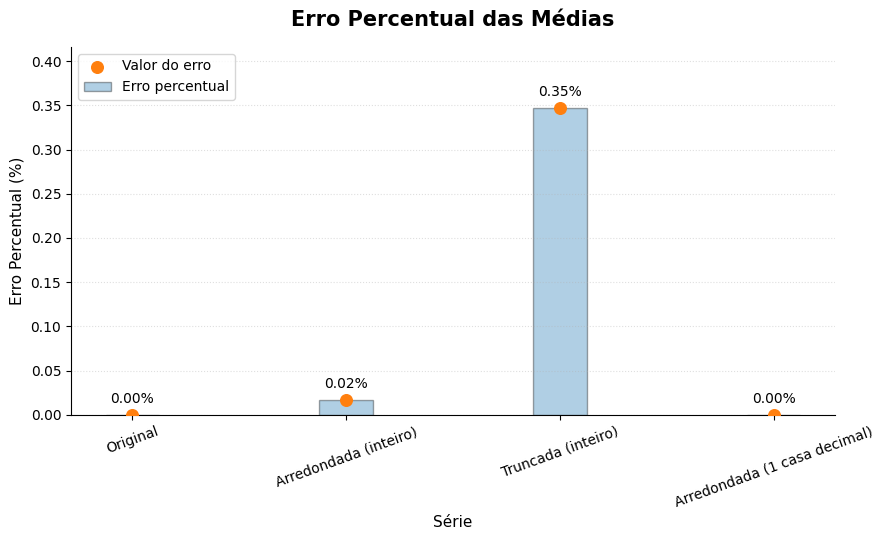

In [47]:
plt.figure(figsize=(9, 5.5))

valores = tabela_erros["Erro Percentual (%)"]

barras = plt.bar(
    tabela_erros["Série"],
    valores,
    width=0.25,
    alpha=0.35,
    edgecolor="black",
    linewidth=1,
    label="Erro percentual"
)

# Pontos sobre as barras
plt.scatter(
    tabela_erros["Série"],
    valores,
    s=70,
    zorder=3,
    label="Valor do erro"
)

# Valores
for i, valor in enumerate(valores):
    plt.text(
        i,
        valor + valores.max() * 0.03,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xlabel("Série", fontsize=11)
plt.ylabel("Erro Percentual (%)", fontsize=11)

plt.title(
    "Erro Percentual das Médias",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xticks(
    rotation=20,
    fontsize=10
)

plt.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)

plt.legend(
    loc="upper left",
    fontsize=10
)

# Remove bordas desnecessárias
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Espaço para os valores acima das barras
plt.ylim(
    0,
    valores.max() * 1.20
)

plt.tight_layout()
plt.show()

### Histograma dos dados originais e dos dados inteiros arredondados.

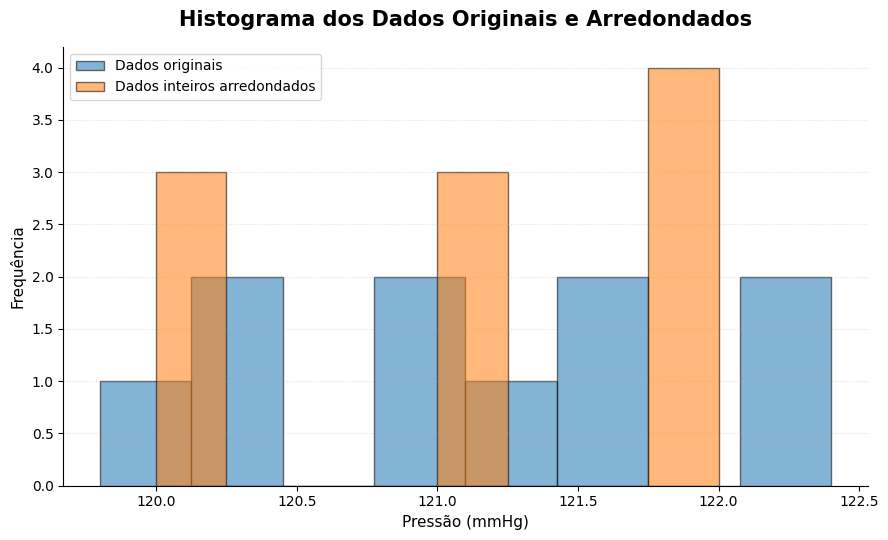

In [50]:
plt.figure(figsize=(9, 5.5))

plt.hist(
    pressao_original,
    bins=8,
    alpha=0.55,
    label="Dados originais",
    edgecolor="black"
)

plt.hist(
    pressao_arred_int,
    bins=8,
    alpha=0.55,
    label="Dados inteiros arredondados",
    edgecolor="black"
)

plt.xlabel("Pressão (mmHg)", fontsize=11)
plt.ylabel("Frequência", fontsize=11)

plt.title(
    "Histograma dos Dados Originais e Arredondados",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)

plt.legend(
    loc="best",
    fontsize=10
)

# Remove bordas desnecessárias
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Explique se a representação inteira é suficiente para preservar a média e a variabilidade desta pequena amostra. Não faça interpretação médica dos valores.

A representação inteira altera a média e a variabilidade em alguma medida, principalmente quando há truncamento, enquanto manter uma casa decimal preserva os valores originais.

# Parte C - Vazão em um tubo de pequeno diâmetro

## C.1 - Precisão das variáveis

Dada a relação de Hagen-Poiseuille: Q = (πr^4∆p) / 8μL, e adotando r = 0.80 mm, L = 0.20 m, μ = 3.5 × 10^−3 Pas, ∆p = 1200 Pa, vamos calcular Q

### Função da vazão

In [52]:
def vazao(r, var_p, mi, L):
  return (np.pi * pow(r, 4) * var_p) / (8 * mi * L)

### Calculando Q com as informações fornecidas

In [53]:
r_C = 0.8 * pow(10, -3)
L_C = 0.20
mi_C = 3.5 * pow(10, -3)
var_p_C = 1200

Q_C = vazao(r_C, var_p_C, mi_C, L_C)

print(f"Vazão original: {Q_C} m^3/s")

Vazão original: 2.757420751950813e-07 m^3/s


### Calculando Q arredondando e truncando o valor do raio em uma casa decimal

In [54]:
r_mm = 0.8

r_arred_mm = round(r_mm, 2)
r_trunc_mm = np.trunc(r_mm * 100) / 100

r_arred = r_arred_mm * pow(10, -3)
r_trunc = r_trunc_mm * pow(10, -3)

print(f"Raio original: {r_C} m\n")
print(f"Raio com raio arredondado: {r_arred} m")
print(f"Raio com raio truncado: {r_trunc} m\n")

Q_r_arred = (np.pi * pow(r_arred, 4) * var_p_C) / (8 * mi_C * L_C)
Q_r_trunc = (np.pi * pow(r_trunc, 4) * var_p_C) / (8 * mi_C * L_C)

print(f"Vazão com raio arredondado: {Q_r_arred} m^3/s")
print(f"Vazão com raio truncado: {Q_r_trunc} m^3/s")

Raio original: 0.0008 m

Raio com raio arredondado: 0.0008 m
Raio com raio truncado: 0.0008 m

Vazão com raio arredondado: 2.757420751950813e-07 m^3/s
Vazão com raio truncado: 2.757420751950813e-07 m^3/s


### Calculando Q arredondando e truncando a viscosidade para 3 casas decimais:

In [55]:
mi_arred = round(mi_C, 3)
mi_trunc = np.trunc(mi_C * 1000) / 1000

print(f"Viscosidade original: {mi_C} Pas\n")
print(f"Viscosidade com viscosidade arredondada: {mi_arred} Pas")
print(f"Viscosidade com viscosidade truncada: {mi_trunc} Pas\n")

Q_mi_arred = (np.pi * pow(r_C, 4) * var_p_C) / (8 * mi_arred * L_C)
Q_mi_trunc = (np.pi * pow(r_C, 4) * var_p_C) / (8 * mi_trunc * L_C)

print(f"Vazão com viscosidade arredondada: {Q_mi_arred} m^3/s")
print(f"Vazão com viscosidade truncada: {Q_mi_trunc} m^3/s")

Viscosidade original: 0.0035 Pas

Viscosidade com viscosidade arredondada: 0.004 Pas
Viscosidade com viscosidade truncada: 0.003 Pas

Vazão com viscosidade arredondada: 2.4127431579569616e-07 m^3/s
Vazão com viscosidade truncada: 3.2169908772759484e-07 m^3/s


### Calculando Q arredondando e truncando a pressão para centenas casas decimais

In [56]:
var_p_arred = round(var_p_C, -2)
var_p_trunc = np.trunc(var_p_C / 100) * 100

print(f"Pressão original: {var_p_C} Pa\n")
print(f"Pressão com pressão arredondada: {var_p_arred} Pa")
print(f"Pressão com pressão truncada: {var_p_trunc} Pa\n")

Q_var_p_arred = (np.pi * pow(r_C, 4) * var_p_arred) / (8 * mi_C * L_C)
Q_var_p_trunc = (np.pi * pow(r_C, 4) * var_p_trunc) / (8 * mi_C * L_C)

print(f"Vazão com pressão arredondada: {Q_var_p_arred} m^3/s")
print(f"Vazão com pressão truncada: {Q_var_p_trunc} m^3/s")

Pressão original: 1200 Pa

Pressão com pressão arredondada: 1200 Pa
Pressão com pressão truncada: 1200.0 Pa

Vazão com pressão arredondada: 2.757420751950813e-07 m^3/s
Vazão com pressão truncada: 2.757420751950813e-07 m^3/s


### Calculando Q com todas as aproximações simultaneamente

In [57]:
#arredondadas
r_todas_aprox_arred = 0.8 * pow(10, -3)
mi_todas_aprox_arred = 0.004
var_p_todas_aprox_arred = 1200

Q_todas_aprox_arred = np.pi * pow(r_todas_aprox_arred, 4) * var_p_todas_aprox_arred / (8 * mi_todas_aprox_arred * L_C)

print(f"Vazão com todas as aproximações arredondadas simultaneamente: {Q_todas_aprox_arred} m^3/s")

#truncadas
r_todas_aprox_trunc = 0.8 * pow(10, -3)
mi_todas_aprox_trunc = 0.003
var_p_todas_aprox_trunc = 1200

Q_todas_aprox_trunc = np.pi * pow(r_todas_aprox_trunc, 4) * var_p_todas_aprox_trunc / (8 * mi_todas_aprox_trunc * L_C)

print(f"Vazão com todas as aproximações truncadas simultaneamente: {Q_todas_aprox_trunc} m^3/s")

Vazão com todas as aproximações arredondadas simultaneamente: 2.4127431579569616e-07 m^3/s
Vazão com todas as aproximações truncadas simultaneamente: 3.2169908772759484e-07 m^3/s


### Calculando os erros de Q em cada cenário e inserindo em uma tabela

In [58]:
#definindo a função dos erros
def calcular_erros(Q_original, Q_aproximado):
  Ea = abs(Q_original - Q_aproximado)
  Er = Ea / abs(Q_original)
  Ep = Er * 100

  return Ea, Er, Ep

Q_original = (np.pi * pow(r_C, 4) * var_p_C) / (8 * mi_C * L_C)

cenarios = {
    "Raio Arredondado": Q_r_arred,
    "Raio Truncado": Q_r_trunc,
    "Viscosidade Arredondado": Q_mi_arred,
    "Viscosidade Truncado": Q_mi_trunc,
    "Pressão Arredondada": Q_var_p_arred,
    "Pressão Truncada": Q_var_p_trunc,
    "Todas as Aproximações Arredondadas": Q_todas_aprox_arred,
    "Todas as Aproximações Truncadas": Q_todas_aprox_trunc
}

resultados = []

print(f"Q_original = {Q_original} m^3/s\n")

for nome, Q_aproximado in cenarios.items():
  Ea, Er, Ep = calcular_erros(Q_original, Q_aproximado)
  resultados.append([nome, Q_aproximado, Ea, Er, Ep])

tabela_erros = pd.DataFrame(resultados, columns = [
    "Cenário",
    "Q (m^3;s)",
    "Erro Absoluto",
    "Erro Relativo",
    "Erro Percentual (%)"
])

tabela_erros["Erro Percentual (%)"] = tabela_erros["Erro Percentual (%)"].map(lambda x: f"{x:.2f}%")

display(tabela_erros)

Q_original = 2.757420751950813e-07 m^3/s



,Cenário,Q (m^3;s),Erro Absoluto,Erro Relativo,Erro Percentual (%)
0,Raio Arredondado,2.757421e-07,0.000000e+00,0.000000,0.00%
1,Raio Truncado,2.757421e-07,0.000000e+00,0.000000,0.00%
2,Viscosidade Arredondado,2.412743e-07,3.446776e-08,0.125000,12.50%
3,Viscosidade Truncado,3.216991e-07,4.595701e-08,0.166667,16.67%
4,Pressão Arredondada,2.757421e-07,0.000000e+00,0.000000,0.00%
5,Pressão Truncada,2.757421e-07,0.000000e+00,0.000000,0.00%
6,Todas as Aproximações Arredondadas,2.412743e-07,3.446776e-08,0.125000,12.50%
7,Todas as Aproximações Truncadas,3.216991e-07,4.595701e-08,0.166667,16.67%


## C.2 - Sensibilidade

raios_ = 0.700000 mm | arred = 0.700000 mm | trunc = 0.700000 mm | Q referência = 1.616349e-07 | Q arred = 1.616349e-07 | Q trunc = 1.616349e-07
raios_ = 0.702020 mm | arred = 0.700000 mm | trunc = 0.700000 mm | Q referência = 1.635090e-07 | Q arred = 1.616349e-07 | Q trunc = 1.616349e-07
raios_ = 0.704040 mm | arred = 0.700000 mm | trunc = 0.700000 mm | Q referência = 1.653992e-07 | Q arred = 1.616349e-07 | Q trunc = 1.616349e-07
raios_ = 0.706061 mm | arred = 0.700000 mm | trunc = 0.700000 mm | Q referência = 1.673058e-07 | Q arred = 1.616349e-07 | Q trunc = 1.616349e-07
raios_ = 0.708081 mm | arred = 0.700000 mm | trunc = 0.700000 mm | Q referência = 1.692288e-07 | Q arred = 1.616349e-07 | Q trunc = 1.616349e-07
raios_ = 0.710101 mm | arred = 0.700000 mm | trunc = 0.700000 mm | Q referência = 1.711684e-07 | Q arred = 1.616349e-07 | Q trunc = 1.616349e-07
raios_ = 0.712121 mm | arred = 0.700000 mm | trunc = 0.700000 mm | Q referência = 1.731246e-07 | Q arred = 1.616349e-07 | Q trunc 

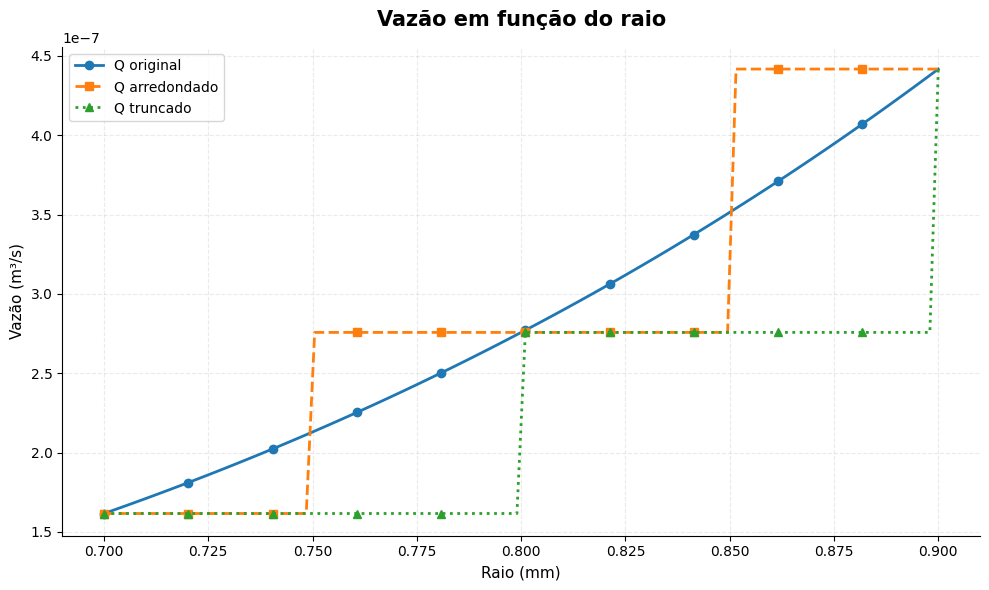

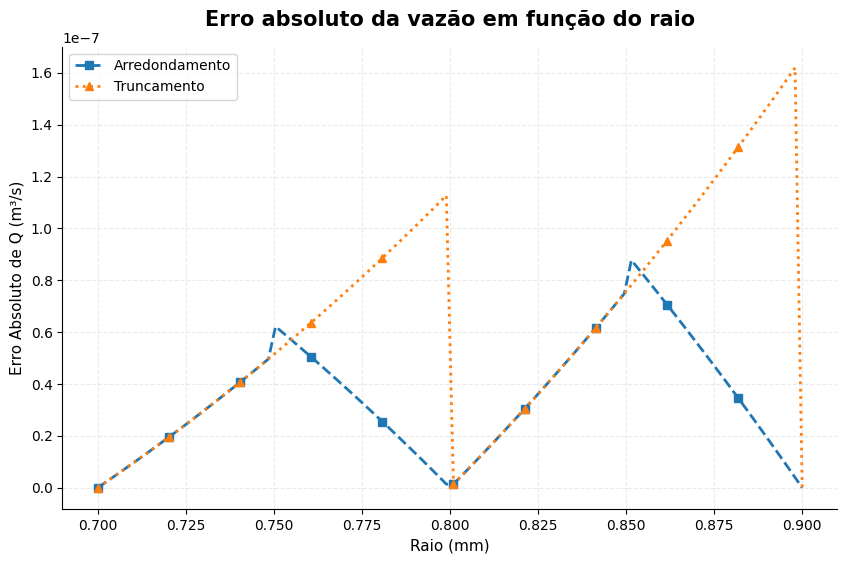

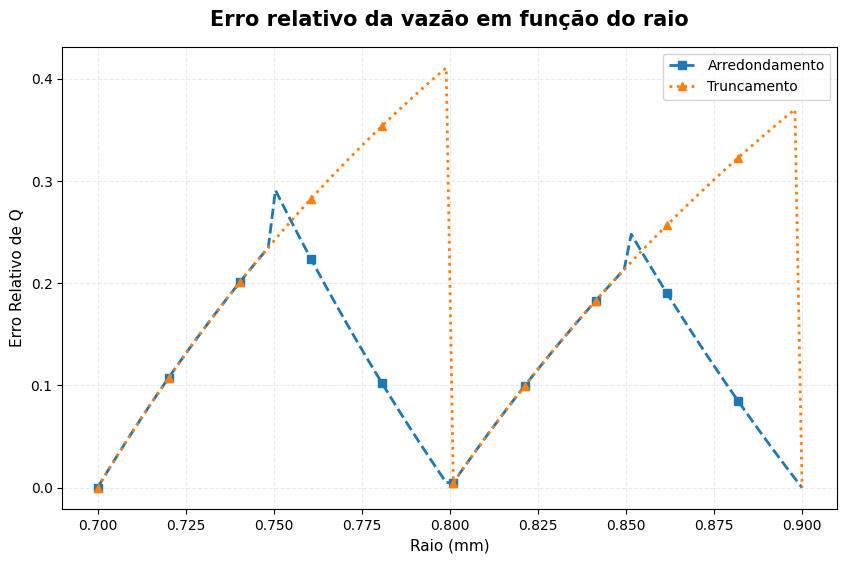

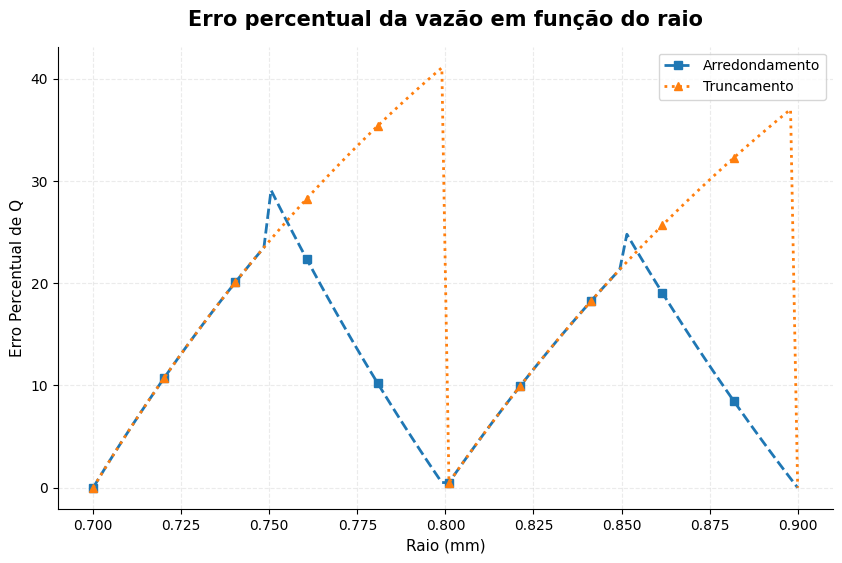

In [59]:
#criar valores do raio em mm
raios_mm = np.linspace(0.70, 0.90, 100)

#raio original em mm
raios_arred_mm = np.round(raios_mm, 1)
raios_trunc_mm = np.trunc(raios_mm * 10) / 10

#raio original em m
raios_m = raios_mm * pow(10, -3)
raios_arred_m = raios_arred_mm * pow(10, -3)
raios_trunc_m = raios_trunc_mm * pow(10, -3)

#calculando as vazões
Q_original = (np.pi * pow(raios_m, 4) * var_p_C) / (8 * mi_C * L_C)
Q_arred = (np.pi * pow(raios_arred_m, 4) * var_p_C) / (8 * mi_C * L_C)
Q_trunc = (np.pi * pow(raios_trunc_m, 4) * var_p_C) / (8 * mi_C * L_C)

#calculando o erro absoluto
Ea_arred = np.abs(Q_original - Q_arred)
Ea_trunc = np.abs(Q_original - Q_trunc)

#calculando o erro relativo
Er_arred = Ea_arred / np.abs(Q_original)
Er_trunc = Ea_trunc / np.abs(Q_original)

#calculando o erro percentual
Ep_arred = Er_arred * 100
Ep_trunc = Er_trunc * 100

for i in range(10):
    print(
        f"raios_ = {raios_mm[i]:f} mm | "
        f"arred = {raios_arred_mm[i]:f} mm | "
        f"trunc = {raios_trunc_mm[i]:f} mm | "
        f"Q referência = {Q_original[i]:e} | "
        f"Q arred = {Q_arred[i]:e} | "
        f"Q trunc = {Q_trunc[i]:e}"
    )

#grafico de Q
plt.figure(figsize = (10, 6))

plt.plot(raios_mm, Q_original, marker = "o", markevery = 10, linewidth = 2, label = "Q original")
plt.plot(raios_mm, Q_arred, marker = "s", markevery = 10, linestyle = "--", linewidth = 2, label = "Q arredondado")
plt.plot(raios_mm, Q_trunc,marker = "^", markevery = 10, linestyle = ":", linewidth = 2, label = "Q truncado")

plt.xlabel("Raio (mm)", fontsize = 11)
plt.ylabel("Vazão (m³/s)", fontsize = 11)
plt.title("Vazão em função do raio", fontsize = 15, fontweight = "bold", pad = 15)

plt.grid(True, linestyle = "--", alpha = 0.25)
plt.legend(fontsize = 10)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#grafico do erro absoluto
plt.figure(figsize=(10, 6))

plt.plot(raios_mm, Ea_arred, marker = "s", markevery = 10, linestyle = "--", linewidth = 2, label="Arredondamento")
plt.plot(raios_mm, Ea_trunc, marker = "^", markevery = 10, linestyle = ":", linewidth = 2, label="Truncamento")

plt.xlabel("Raio (mm)", fontsize = 11)
plt.ylabel("Erro Absoluto de Q (m³/s)", fontsize = 11)
plt.title("Erro absoluto da vazão em função do raio", fontsize = 15, fontweight = "bold", pad = 15)

plt.grid(True, linestyle = "--", alpha = 0.25)

plt.legend(fontsize = 10)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

#grafico do erro relativo
plt.figure(figsize = (10, 6))

plt.plot(raios_mm, Er_arred, marker = "s", markevery = 10, linestyle = "--", linewidth = 2, label = "Arredondamento")
plt.plot(raios_mm, Er_trunc, marker = "^", markevery = 10, linestyle = ":", linewidth = 2,label = "Truncamento")

plt.xlabel("Raio (mm)", fontsize = 11)
plt.ylabel("Erro Relativo de Q", fontsize = 11)
plt.title("Erro relativo da vazão em função do raio", fontsize = 15, fontweight = "bold", pad = 15)

plt.grid(True, linestyle = "--", alpha = 0.25)
plt.legend(fontsize = 10)

plt.show()

#grafico do erro percentual
plt.figure(figsize = (10, 6))

plt.plot(raios_mm, Ep_arred, marker = "s", markevery = 10, linestyle = "--", linewidth = 2, label = "Arredondamento")
plt.plot(raios_mm, Ep_trunc, marker = "^", markevery = 10, linestyle = ":", linewidth = 2, label = "Truncamento")

plt.xlabel("Raio (mm)", fontsize = 11)
plt.ylabel("Erro Percentual de Q", fontsize = 11)
plt.title("Erro percentual da vazão em função do raio", fontsize = 15, fontweight = "bold", pad = 15)

plt.grid(True, linestyle = "--", alpha = 0.25)
plt.legend(fontsize = 10)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

### Explique por que o erro no raio é amplificado na vazão. Relacione sua resposta ao expoente quatro.

O erro no raio acaba sendo amplificado na vazão pois na fórmula de Poiseuille, o raio aparece elevado a quarta potência. E como o Q é proporcional ao raio, se houver uma mínima variação no raio, a vazão sofrerá uma grande variação. Por exemplo, se houver uma variação de 1% do raio, a vazão sofrerá uma variação 4 vezes maior, ou seja 4%.

# Parte D - escoamento de um nanocateter

## D.1 - Erro geométrico

### Considerando os dados de um nanocateter fornecidos no problema temos:

In [61]:
r_D = 50 * pow(10, -9) #50 nano metro
L_D = 10 * pow(10, -6) #10 micro metro
mi_D = 3.5 * pow(10, -3) #Pas
var_p_D = 5000 #Pa

#definindo a funcao da vazao
def calcular_Q_D(r):
  return (np.pi * pow(r, 4) * var_p_D) / (8 * mi_D * L_D)

  print(f"r = {r_D:.2e} m")
print(f"r = {r_D * 1e9:.1f} nm")

r = 50.0 nm


### Calculando a vazão de referência

In [67]:
Q_D = calcular_Q_D(r_D)

print(f"Vazão original: {Q_original} m^3/s")

Vazão original: 3.506241800881467e-19 m^3/s


### Criando os valores de delta r, seguindo o intervalo do exercicio de 0,1, 0,2, 0,3, ..., 5,0 nm, temos

In [68]:
delta_r_nm = np.arange(0.1, 5.1, 0.1)
delta_r_m = delta_r_nm * pow(10, -9) #converte de nm para m

print(f"Delta r em nm: {delta_r_nm}\n")
print(f"Delta r em m: {delta_r_m}")

Delta r em nm: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8
 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6
 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9 5. ]

Delta r em m: [1.0e-10 2.0e-10 3.0e-10 4.0e-10 5.0e-10 6.0e-10 7.0e-10 8.0e-10 9.0e-10
 1.0e-09 1.1e-09 1.2e-09 1.3e-09 1.4e-09 1.5e-09 1.6e-09 1.7e-09 1.8e-09
 1.9e-09 2.0e-09 2.1e-09 2.2e-09 2.3e-09 2.4e-09 2.5e-09 2.6e-09 2.7e-09
 2.8e-09 2.9e-09 3.0e-09 3.1e-09 3.2e-09 3.3e-09 3.4e-09 3.5e-09 3.6e-09
 3.7e-09 3.8e-09 3.9e-09 4.0e-09 4.1e-09 4.2e-09 4.3e-09 4.4e-09 4.5e-09
 4.6e-09 4.7e-09 4.8e-09 4.9e-09 5.0e-09]


### Calculando r_menor e r_maior

In [69]:
#pela definção do enunciado
r_menor = r_D - delta_r_m
r_maior = r_D + delta_r_m

### Calculando as três vazões, Q(r_menor), Q(r) e Q(r_maior)

In [71]:
Q_menor = calcular_Q_D(r_menor)
Q_D = calcular_Q_D(r_D)
Q_maior = calcular_Q_D(r_maior)

for i in range(5):
  print(
      f"delta_r = {delta_r_nm[i]:.1f} nm | "
      f"r_menor = {r_menor[i] * 1e9:.1f} m | "
      f"r_maior = {r_maior[i]*1e9:.1f} m | "
      f"Q(r_menor) = {Q_menor[i]:.6e} | "
      f"Q(r) = {Q_D:.6e} | "
      f"Q(r_maior) = {Q_maior[i]:.6e}"
  )

delta_r = 0.1 nm | r_menor = 49.9 m | r_maior = 50.1 m | Q(r_menor) = 3.478276e-19 | Q(r) = 3.506242e-19 | Q(r_maior) = 3.534376e-19
delta_r = 0.2 nm | r_menor = 49.8 m | r_maior = 50.2 m | Q(r_menor) = 3.450478e-19 | Q(r) = 3.506242e-19 | Q(r_maior) = 3.562679e-19
delta_r = 0.3 nm | r_menor = 49.7 m | r_maior = 50.3 m | Q(r_menor) = 3.422846e-19 | Q(r) = 3.506242e-19 | Q(r_maior) = 3.591152e-19
delta_r = 0.4 nm | r_menor = 49.6 m | r_maior = 50.4 m | Q(r_menor) = 3.395381e-19 | Q(r) = 3.506242e-19 | Q(r_maior) = 3.619795e-19
delta_r = 0.5 nm | r_menor = 49.5 m | r_maior = 50.5 m | Q(r_menor) = 3.368082e-19 | Q(r) = 3.506242e-19 | Q(r_maior) = 3.648609e-19


### Gráfico das vazões

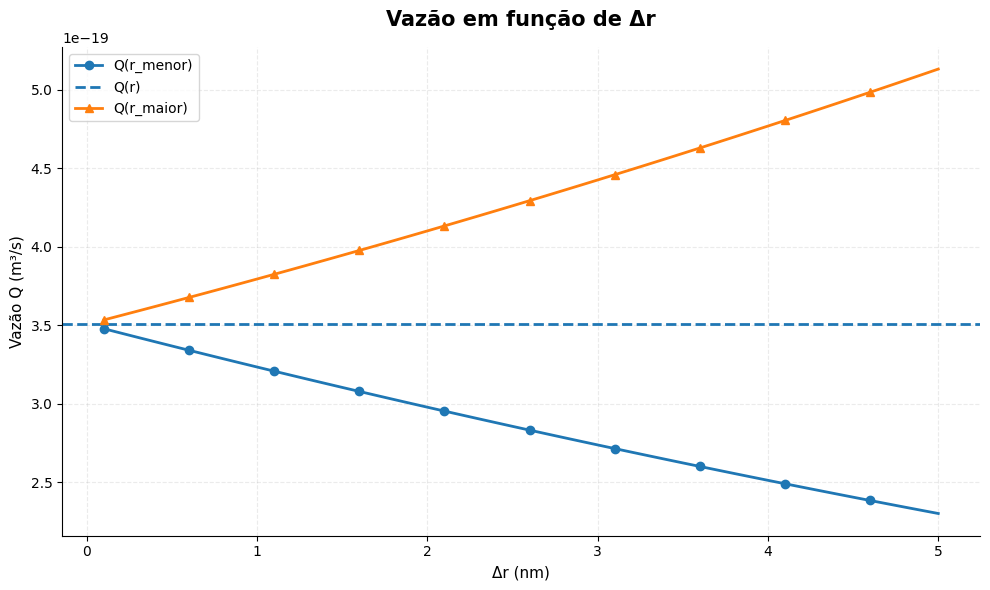

In [73]:
plt.figure(figsize = (10, 6))

plt.plot(delta_r_nm, Q_menor, marker = "o", markevery = 5, linewidth = 2, label = "Q(r_menor)")
plt.axhline(Q_D, linestyle = "--", linewidth = 2, label = "Q(r)")
plt.plot(delta_r_nm, Q_maior, marker = "^", markevery = 5, linewidth = 2, label = "Q(r_maior)")

plt.xlabel("Δr (nm)", fontsize = 11)
plt.ylabel("Vazão Q (m³/s)", fontsize = 11)
plt.title("Vazão em função de Δr", fontsize = 15, fontweight = "bold", pad = 15)

plt.grid(True, linestyle = "--", alpha = 0.25)
plt.legend(fontsize = 10)

# Remove bordas superior e direita
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Grafico do erro absoluto máximo

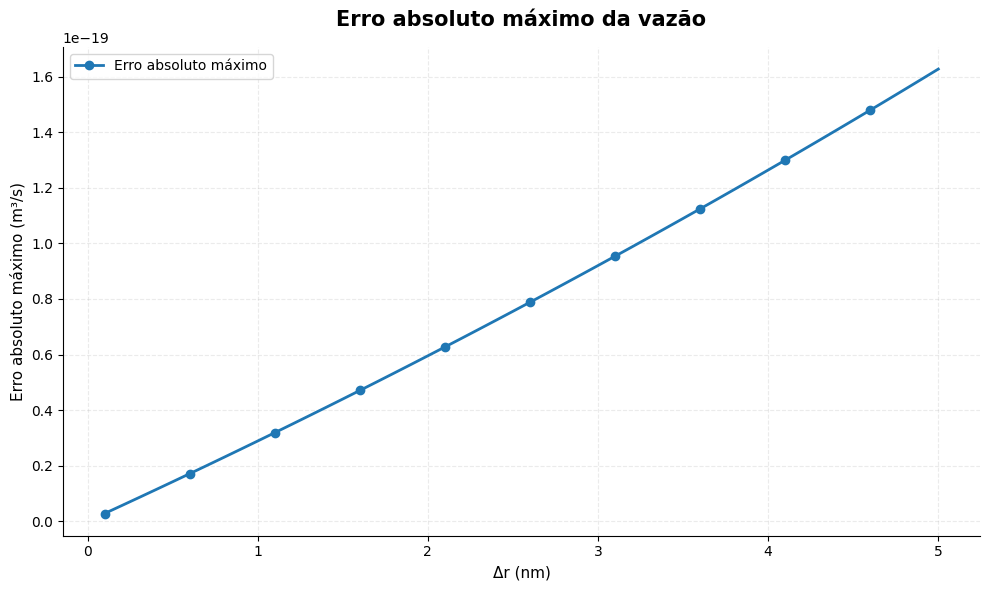

In [76]:
erro_abs_menor = np.abs(Q_D - Q_menor)
erro_abs_maior = np.abs(Q_maior - Q_D)

erro_abs_max = np.maximum(erro_abs_menor, erro_abs_maior)

plt.figure(figsize = (10, 6))

plt.plot(delta_r_nm, erro_abs_max, marker = "o", markevery = 5, linewidth = 2, label = "Erro absoluto máximo")

plt.xlabel("Δr (nm)", fontsize = 11)
plt.ylabel("Erro absoluto máximo (m³/s)", fontsize = 11)
plt.title("Erro absoluto máximo da vazão", fontsize = 15, fontweight = "bold", pad = 15)

plt.grid(True, linestyle = "--", alpha = 0.25)
plt.legend(fontsize = 10)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Gráfico do erro relativo máximo

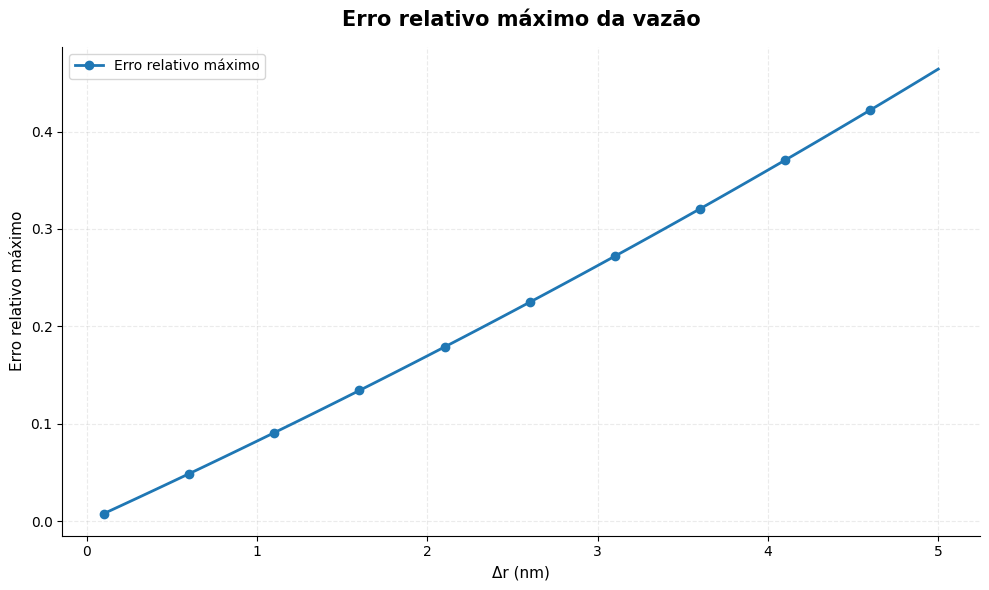

In [77]:
erro_rel_max = erro_abs_max / abs(Q_D)

plt.figure(figsize = (10, 6))

plt.plot(delta_r_nm, erro_rel_max, marker = "o", markevery = 5, linewidth = 2, label = "Erro relativo máximo")

plt.xlabel("Δr (nm)", fontsize = 11)
plt.ylabel("Erro relativo máximo", fontsize = 11)
plt.title("Erro relativo máximo da vazão", fontsize = 15, fontweight = "bold", pad = 15)

plt.grid(True, linestyle = "--", alpha = 0.25)

plt.legend(fontsize = 10)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Gráfico do erro percentual máximo

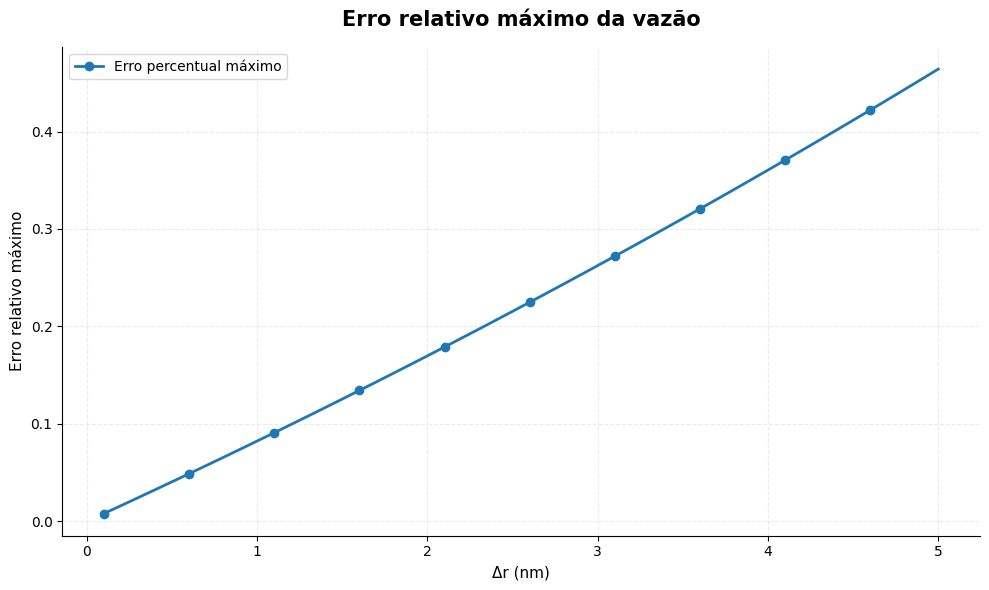

In [78]:
erro_perc_max = erro_rel_max * 100

plt.figure(figsize = (10, 6))

plt.plot(delta_r_nm, erro_rel_max, marker = "o", markevery = 5, linewidth = 2, label = "Erro percentual máximo")

plt.xlabel("Δr (nm)", fontsize = 11)
plt.ylabel("Erro relativo máximo", fontsize = 11)
plt.title("Erro relativo máximo da vazão", fontsize = 15, fontweight = "bold", pad = 15)

plt.grid(True, linestyle = "--", alpha = 0.25)

plt.legend(fontsize = 10)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Para comparar o erro direto com a aproximação linear, utiizando ∆Q/Q ≈ 4∆r/r, fornecida pelo enunciado calcularemos a aproximação linear

Aproximação linear: [0.008 0.016 0.024 0.032 0.04  0.048 0.056 0.064 0.072 0.08  0.088 0.096
 0.104 0.112 0.12  0.128 0.136 0.144 0.152 0.16  0.168 0.176 0.184 0.192
 0.2   0.208 0.216 0.224 0.232 0.24  0.248 0.256 0.264 0.272 0.28  0.288
 0.296 0.304 0.312 0.32  0.328 0.336 0.344 0.352 0.36  0.368 0.376 0.384
 0.392 0.4  ]


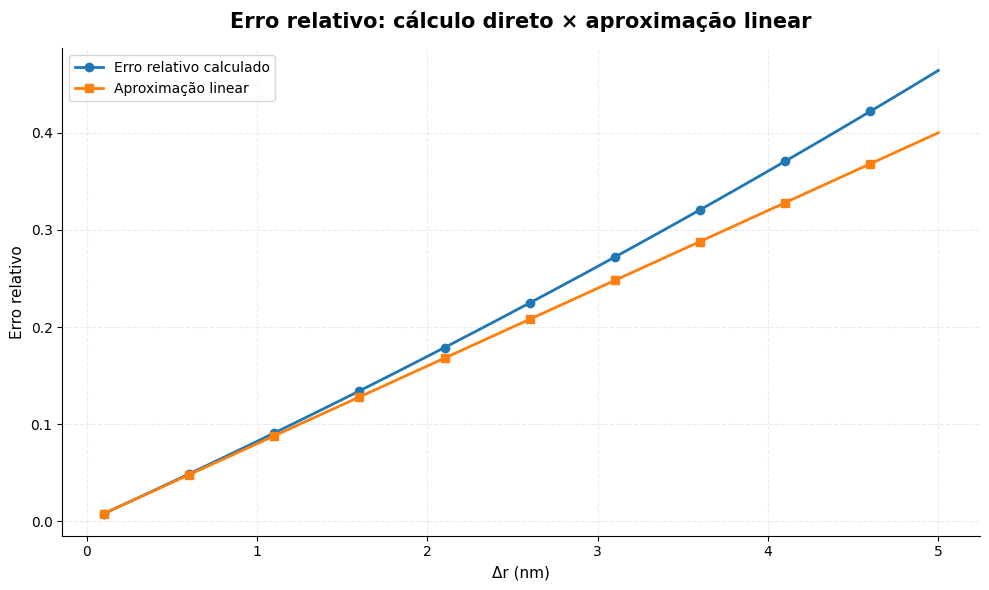

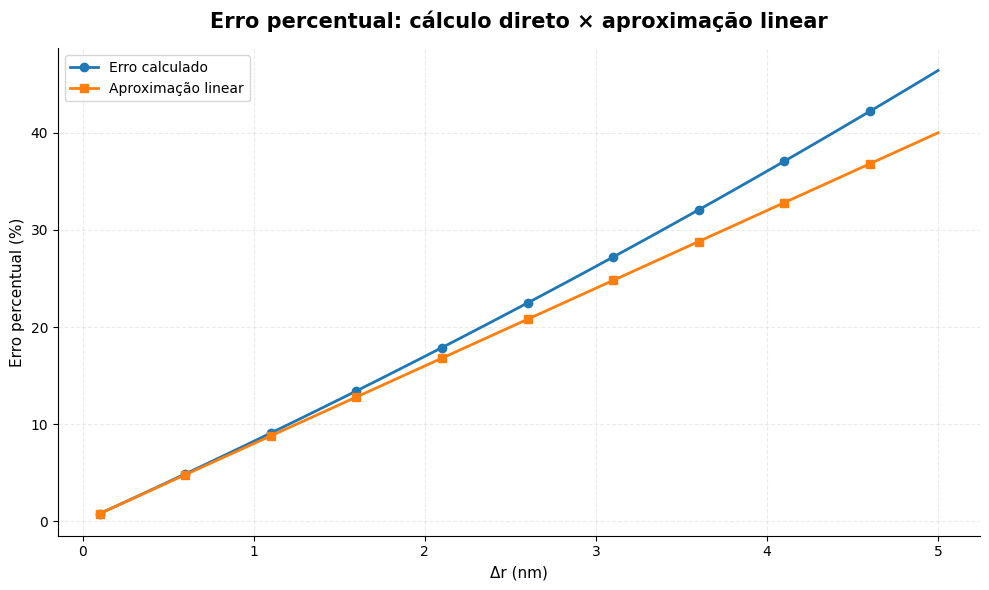

In [81]:
erro_linear = 4 * delta_r_m / r_D

print(f"Aproximação linear: {erro_linear}")

#fazendo um gráfico para comparar os valores obtidos
plt.figure(figsize = (10, 6))

plt.plot(delta_r_nm, erro_rel_max, marker = "o", markevery = 5, linewidth = 2, label = "Erro relativo calculado")
plt.plot(delta_r_nm, erro_linear,  marker = "s", markevery = 5, linewidth = 2, label = "Aproximação linear")

plt.xlabel("Δr (nm)", fontsize = 11)
plt.ylabel("Erro relativo", fontsize = 11)
plt.title("Erro relativo: cálculo direto × aproximação linear", fontsize = 15, fontweight = "bold", pad = 15)

plt.grid(True, linestyle = "--", alpha = 0.25)
plt.legend(fontsize = 10)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

print("\n")

#teste
erro_linear_percentual = erro_linear * 100

plt.figure(figsize=(10, 6))

plt.plot(delta_r_nm, erro_perc_max, marker = "o", markevery = 5, linewidth = 2, label="Erro calculado")
plt.plot(delta_r_nm, erro_linear_percentual, marker = "s", markevery = 5, linewidth = 2, label="Aproximação linear")

plt.xlabel("Δr (nm)", fontsize = 11)
plt.ylabel("Erro percentual (%)", fontsize = 11)
plt.title("Erro percentual: cálculo direto × aproximação linear", fontsize = 15, fontweight = "bold", pad = 15)

plt.grid(True, linestyle = "--", alpha = 0.25)
plt.legend(fontsize = 10)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

### Compare o erro direto com a aproximação linear.

De um modo geral, a aproximação linear ∆Q/Q ≈ 4∆r/r apresenta uma boa concordância com o erro relativo quando usamos pequenos valores para o ∆r. A partir do momento que o ∆r aumenta gradativamente, a diferença entre o erro calculado com a aproximação linear também aumenta graadativamente. Esse aumento gradativo ocorre por conta do do raio estar elevado a quarta, consequentemente, qualquer pequena variação no raio gera alterações na vazão.

## D.2 Precisão computacional

### Criando as versões propostas pelo enunciado, float32 e float64, utilizando os mesmos dados da D.1, temos

In [82]:
r_D = 50 * pow(10, -9)
L_D = 10 * pow(10, -6)
mi_D = 3.5 * pow(10, -3)
var_p_D = 5000

r32 = np.float32(r_D)
r64 = np.float64(r_D)

L32 = np.float32(L_D)
L64 = np.float64(L_D)

mi32 = np.float32(mi_D)
mi64 = np.float64(mi_D)

var_p32 = np.float32(var_p_D)
var_p64 = np.float64(var_p_D)

#calculando r^4 para float32 e float64
r4_32 = pow(r32, 4)
r4_64 = pow(r64, 4)

print(f"r^4 float32: {r4_32}")
print(f"r^4 float64: {r4_64}\n")

#Calculando Q para as versões
Q_32 = np.float32(np.pi) * r4_32 * var_p32 / (8 * mi32 * L32)
Q_64 = np.float64(np.pi) * r4_64 * var_p64 / (8 * mi64 * L64)

print(f"Q_float32: {Q_32}")
print(f"Q_float64: {Q_64}\n")

#calculando a diferença absoluta
dif_abs = abs(float(Q_32) - float(Q_64))

print(f"Diferença absoluta: {dif_abs}\n")

#calculando a diferença relativa
dif_rel = dif_abs/abs(float(Q_64))

print(f"Diferença relativa: {dif_rel}\n")

#calculando a diferença percentual
dif_perc = dif_rel * 100

print(f"Diferença percentual: {dif_perc}%\n")

#calculando np.info(...).eps de cada tipo
eps_32 = np.finfo(np.float32).eps
eps_64 = np.finfo(np.float64).eps

print(f"eps float32: {eps_32}")
print(f"eps float64: {eps_64}\n")

r^4 float32: 6.2500003959774226e-30
r^4 float64: 6.250000000000002e-30

Q_float32: 3.506242323744234e-19
Q_float64: 3.506241800881467e-19

Diferença absoluta: 5.228627669925028e-26

Diferença relativa: 1.4912341951460834e-07

Diferença percentual: 1.4912341951460834e-05%

eps float32: 1.1920928955078125e-07
eps float64: 2.220446049250313e-16



### Calculando a variação de vazão das duas formas fornecidas pelo enunciado

In [83]:
#adotando delta_r = 0.1 nm
delta_r = 0.1 * pow(10, -9)

#calculando delta1
Q_r = calcular_Q_D(r_D)
Q_r_delta = calcular_Q_D(r_D + delta_r)

delta1 = (Q_r_delta - Q_r) / Q_r

print(f"delta1: {delta1}")
#calculando delta2
delta2 = pow((1 + delta_r / r_D), 4) - 1

print(f"delta2: {delta2}")

delta1: 0.008024032016000186
delta2: 0.008024032016000104


### Repetindo agora para valores progressivamente menores de ∆r/r, a fim de identificar uma possível perda de significância por cancelamento

In [84]:
razoes = pow(10.0, (-np.arange(1, 11)))

resultados = []

for razao in razoes:
  delta_r = razao * r_D

  Q_r = calcular_Q_D(r_D)
  Q_r_delta = calcular_Q_D(r_D + delta_r)

  delta1 = (Q_r_delta - Q_r) / Q_r
  delta2 = pow((1 + razao), 4) - 1

  resultados.append([
      razao, delta1, delta2
  ])

  #inserindo os dados em uma tabela
  tabela_d2 = pd.DataFrame(
      resultados,
      columns = [
        "Δr/r",
        "δ1",
        "δ2"
      ]
  )

  display(tabela_d2)

,Δr/r,δ1,δ2
0,0.1,0.4641,0.4641


,Δr/r,δ1,δ2
0,0.10,0.464100,0.464100
1,0.01,0.040604,0.040604


,Δr/r,δ1,δ2
0,0.100,0.464100,0.464100
1,0.010,0.040604,0.040604
2,0.001,0.004006,0.004006


,Δr/r,δ1,δ2
0,0.1000,0.464100,0.464100
1,0.0100,0.040604,0.040604
2,0.0010,0.004006,0.004006
3,0.0001,0.000400,0.000400


,Δr/r,δ1,δ2
0,0.10000,0.464100,0.464100
1,0.01000,0.040604,0.040604
2,0.00100,0.004006,0.004006
3,0.00010,0.000400,0.000400
4,0.00001,0.000040,0.000040


,Δr/r,δ1,δ2
0,0.100000,0.464100,0.464100
1,0.010000,0.040604,0.040604
2,0.001000,0.004006,0.004006
3,0.000100,0.000400,0.000400
4,0.000010,0.000040,0.000040
5,0.000001,0.000004,0.000004


,Δr/r,δ1,δ2
0,1.000000e-01,4.641000e-01,4.641000e-01
1,1.000000e-02,4.060401e-02,4.060401e-02
2,1.000000e-03,4.006004e-03,4.006004e-03
3,1.000000e-04,4.000600e-04,4.000600e-04
4,1.000000e-05,4.000060e-05,4.000060e-05
5,1.000000e-06,4.000006e-06,4.000006e-06
6,1.000000e-07,4.000001e-07,4.000001e-07


,Δr/r,δ1,δ2
0,1.000000e-01,4.641000e-01,4.641000e-01
1,1.000000e-02,4.060401e-02,4.060401e-02
2,1.000000e-03,4.006004e-03,4.006004e-03
3,1.000000e-04,4.000600e-04,4.000600e-04
4,1.000000e-05,4.000060e-05,4.000060e-05
5,1.000000e-06,4.000006e-06,4.000006e-06
6,1.000000e-07,4.000001e-07,4.000001e-07
7,1.000000e-08,4.000000e-08,4.000000e-08


,Δr/r,δ1,δ2
0,1.000000e-01,4.641000e-01,4.641000e-01
1,1.000000e-02,4.060401e-02,4.060401e-02
2,1.000000e-03,4.006004e-03,4.006004e-03
3,1.000000e-04,4.000600e-04,4.000600e-04
4,1.000000e-05,4.000060e-05,4.000060e-05
5,1.000000e-06,4.000006e-06,4.000006e-06
6,1.000000e-07,4.000001e-07,4.000001e-07
7,1.000000e-08,4.000000e-08,4.000000e-08
8,1.000000e-09,4.000000e-09,4.000000e-09


,Δr/r,δ1,δ2
0,1.000000e-01,4.641000e-01,4.641000e-01
1,1.000000e-02,4.060401e-02,4.060401e-02
2,1.000000e-03,4.006004e-03,4.006004e-03
3,1.000000e-04,4.000600e-04,4.000600e-04
4,1.000000e-05,4.000060e-05,4.000060e-05
5,1.000000e-06,4.000006e-06,4.000006e-06
6,1.000000e-07,4.000001e-07,4.000001e-07
7,1.000000e-08,4.000000e-08,4.000000e-08
8,1.000000e-09,4.000000e-09,4.000000e-09
9,1.000000e-10,4.000003e-10,4.000000e-10


### Compare as duas expressões para valores progressivamente menores de ∆r/r e identifique possível perda de significância por cancelamento.

Quando Δr/r fica muito pequeno, ao realizar Q(r + Δr) e Q(r) os resultados ficam muito próximos. Ao subtrair esses valores, pode vir a ocorrer o cancelamento numérico e perda de algarismos significativos na resposta. Esse caso fica um pouco mais perceptível no float32 que possui uma menor precisão ao compararmos com o float64. Desse modo, ao utilizar o float64, ele acaba fornecendo valores mais confiáveis do que o float32.

## D.3 - Fenômeno físico

### Explique, em um parágrafo, que a redução da escala aumenta a razão superfície/volume e torna os efeitos viscosos e de parede mais importantes.

A redução da escala do sistema pode aumentar a razão entre superfície/volume, consequentemente os possíveis efeitos relacionados à parede podem ter uma maior influência sobre o escoamento. No cenário do nanocateter, os efeitos de viscosidade e de parede se tornam mais importantes e pode interferir diretamente no modo de interpretar a hipótese, uma vez que se afasta do comportamento real. Desse modo, obter um resultado com várias casas decimais não necessariamente significa que seja o resultado mais adequado. A precisão aritmética se relaciona à forma como os cálculos são realizados numericamente, enquanto a validade do modelo depende se as hipóteses utilizadas representarem adequadamente o fenômeno físico estudado anteriormente.

# Parte E - Síntese virtual

## Dados referentes a parte C

In [118]:
r_C = 0.8 * pow(10, -3)
L_C = 0.20
mi_C = 3.5 * pow(10, -3)
var_p_C = 1200

def calcular_Q_C(raio, mi, var_p, L):
  return (np.pi * pow(raio, 4) * var_p) / (8 * mi * L)

 #Vazão original
Q_C = calcular_Q_C(r_C, mi_C, var_p_C, L_C)

#para C.1
#arredondando e truncando mi
mi_C_arred = round(mi_C, 3)
mi_C_trunc = np.trunc(mi_C * 1000) / 1000

#vazão com mi arredondado e truncado
Q_mi_arred = calcular_Q_C(r_C, mi_C_arred, var_p_C, L_C)
Q_mi_trunc = calcular_Q_C(r_C, mi_C_trunc, var_p_C, L_C)

#erro absoluto com mi arredondado e truncado
erro_mi_arred = abs(Q_mi_arred - Q_C)
erro_mi_trunc = abs(Q_mi_trunc - Q_C)

#erro percentual com mi arredondado e truncado
erro_perc_mi_arred = erro_mi_arred / abs(Q_C) * 100
erro_perc_mi_trunc = erro_mi_trunc / abs(Q_C) * 100

#para C.2
#sensibilidade da vazão ao raio
raios_mm = np.arange(0.70, 0.901, 0.01)
raios_m = raios_mm * pow(10, -3)

Q_raios = calcular_Q_C(raios_m, mi_C, var_p_C, L_C)

## Dados referentes a parte D

In [119]:
r_D = 50 * pow(10, -9)
L_D = 10 * pow(10, -6)
mi_D = 3.5 * pow(10, -3)
var_p_D = 5000

def calcular_Q_D(raio):
  return (np.pi * pow(raio, 4) * var_p_D) / (8 * mi_D * L_D)

#vazão original
Q_D = calcular_Q_D(r_D)

r4_D = pow(r_D, 4)

#para D.1
#incerteza do raio
delta_r_nm = np.arange(0.1, 5.1, 0.1)
delta_r_m = delta_r_nm * pow(10, -9)

r_menor = r_D - delta_r_m
r_maior = r_D + delta_r_m

Q_menor = calcular_Q_D(r_menor)
Q_maior = calcular_Q_D(r_maior)

#calculando os erros
erro_abs_menor = np.abs(Q_D - Q_menor)
erro_abs_maior = np.abs(Q_maior - Q_D)

erro_abs_max = np.maximum(erro_abs_menor, erro_abs_maior)

erro_rel_max = erro_abs_max / abs(Q_D)
erro_perc_max = erro_rel_max * 100

#aproximação linear
erro_linear = 4 * delta_r_m / r_D
erro_linear_perc = erro_linear * 100

#para D.2
#float32
r_32 = np.float32(r_D)
L_32 = np.float32(L_D)
mi_32 = np.float32(mi_D)
var_p_32 = np.float32(var_p_D)

r4_32 = pow(r_32, 4)

Q_32 = (np.float32(np.pi) * r4_32 * var_p_32) / (np.float32(8) * mi_32 * L_32)

#float64
r_64 = np.float64(r_D)
L_64 = np.float64(L_D)
mi_64 = np.float64(mi_D)
var_p_64 = np.float64(var_p_D)

r4_64 = pow(r_64, 4)

Q_64 = (np.float64(np.pi) * r4_64 * var_p_64) / (np.float64(8) * mi_64 * L_64)

#calculando as diferenças entre o float32 e o float64
dif_abs = abs(float(Q_32) - float(Q_64))
dif_rel = dif_abs / abs(float(Q_64))
dif_perc = dif_rel * 100

eps_32 = np.finfo(np.float32).eps
eps_64 = np.finfo(np.float64).eps

## Configurando a figura e agrupando os resultados

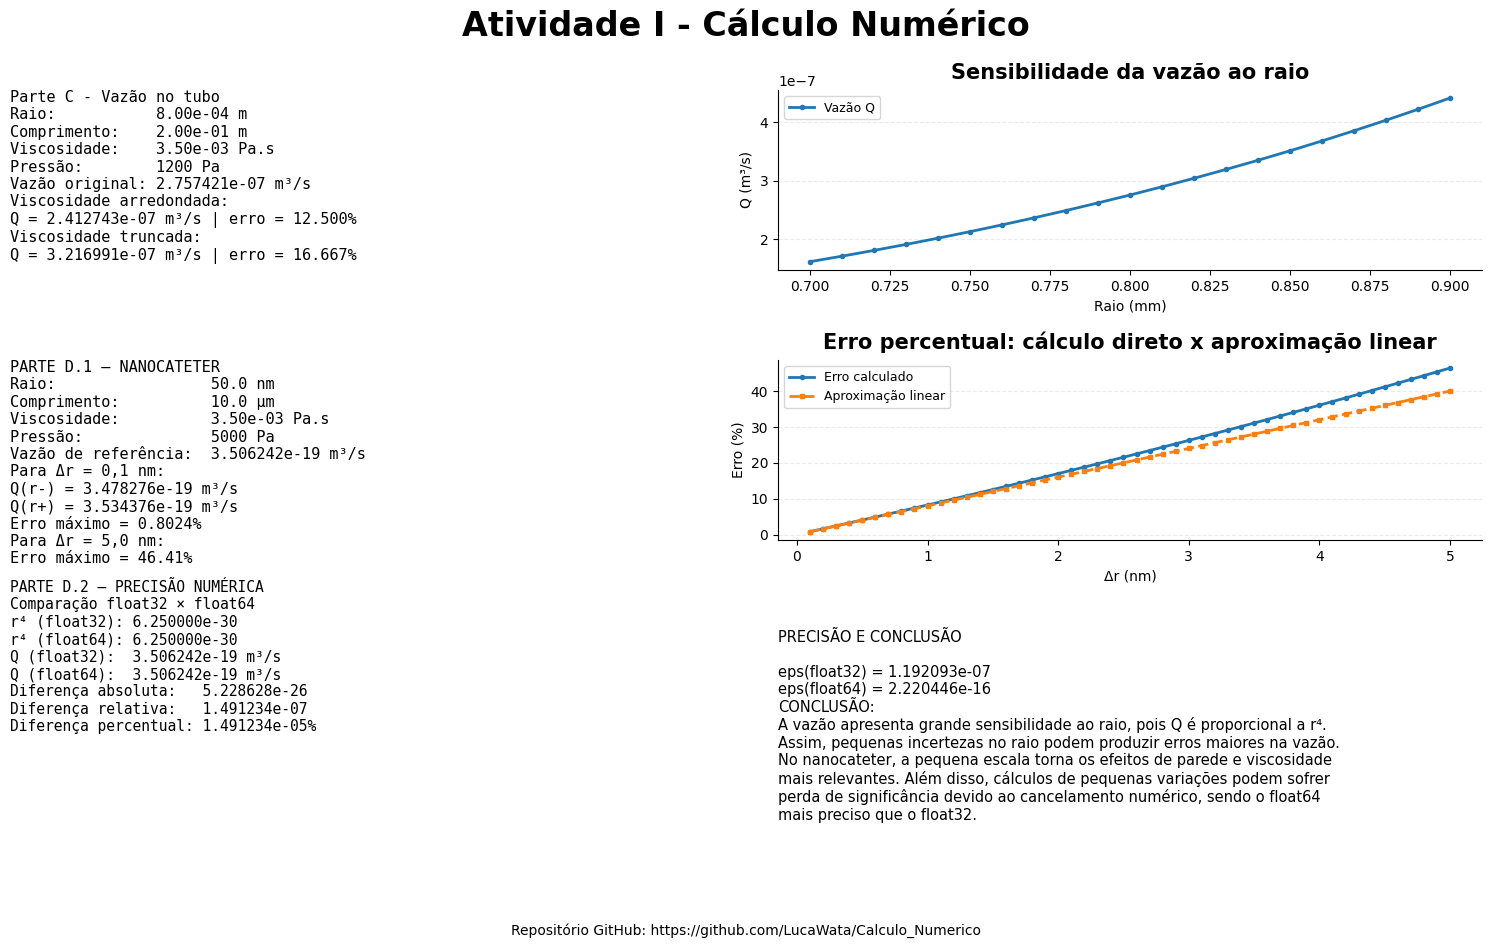

In [128]:
fig = plt.figure(figsize = (16, 10), dpi = 100)

fig.suptitle(
    "Atividade I - Cálculo Numérico",
    fontsize = 24,
    fontweight = "bold",
    y = 0.96
);

#Agrupando os principais resultados da parte C
ax1 = fig.add_axes([0.04, 0.70, 0.42, 0.18])
ax1.axis("off")

texto_C = (
    "Parte C - Vazão no tubo\n"
    f"Raio:           {r_C:.2e} m\n"
    f"Comprimento:    {L_C:.2e} m\n"
    f"Viscosidade:    {mi_C:.2e} Pa.s\n"
    f"Pressão:        {var_p_C:.0f} Pa\n"
    f"Vazão original: {Q_C:.6e} m³/s\n"
    "Viscosidade arredondada:\n"
    f"Q = {Q_mi_arred:.6e} m³/s | erro = {erro_perc_mi_arred:.3f}%\n"
    "Viscosidade truncada:\n"
    f"Q = {Q_mi_trunc:.6e} m³/s | erro = {erro_perc_mi_trunc:.3f}%"
)

ax1.text(
    0, 1, texto_C,
    fontsize = 11,
    verticalalignment = "top",
    family = "monospace"
)

#Gráfico da parte C.2
ax2 = fig.add_axes([0.52, 0.70, 0.44, 0.18])

ax2.plot(raios_mm, Q_raios, marker = "o", markersize = 3, linewidth = 2, label = "Vazão Q")

ax2.set_title(
    "Sensibilidade da vazão ao raio",
    fontsize = 15,
    fontweight = "bold",
    pad = 8
)

ax2.set_xlabel("Raio (mm)", fontsize = 10)
ax2.set_ylabel("Q (m³/s)", fontsize = 10)
ax2.grid(axis = "y", linestyle = "--", alpha = 0.25)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Legenda
ax2.legend(
    fontsize = 9,
    loc = "upper left"
)

#Agrupando, agora, os principais resultados da parte D.1
ax3 = fig.add_axes([0.04, 0.43, 0.42, 0.18])
ax3.axis("off")

texto_D1 = (
    "PARTE D.1 – NANOCATETER\n"
    f"Raio:                 {r_D*1e9:.1f} nm\n"
    f"Comprimento:          {L_D*1e6:.1f} µm\n"
    f"Viscosidade:          {mi_D:.2e} Pa.s\n"
    f"Pressão:              {var_p_D:.0f} Pa\n"
    f"Vazão de referência:  {Q_D:.6e} m³/s\n"
    f"Para Δr = 0,1 nm:\n"
    f"Q(r-) = {Q_menor[0]:.6e} m³/s\n"
    f"Q(r+) = {Q_maior[0]:.6e} m³/s\n"
    f"Erro máximo = {erro_perc_max[0]:.4f}%\n"
    f"Para Δr = 5,0 nm:\n"
    f"Erro máximo = {erro_perc_max[-1]:.2f}%"
)

ax3.text(
    0, 1, texto_D1,
    fontsize = 11,
    verticalalignment = "top",
    family = "monospace"
)

#Plotando o gráfico da parte D.1 - Erro calculado x Aproximação
ax4 = fig.add_axes([0.52, 0.43, 0.44, 0.18])

ax4.plot(
    delta_r_nm,
    erro_perc_max,
    marker = "o",
    markersize = 3,
    linewidth = 2,
    label = "Erro calculado"
)

ax4.plot(
    delta_r_nm,
    erro_linear_perc,
    marker = "s",
    markersize = 3,
    linewidth = 2,
    linestyle = "--",
    label = "Aproximação linear"
)

ax4.set_title(
    "Erro percentual: cálculo direto x aproximação linear",
    fontsize = 15,
    fontweight = "bold",
    pad = 8
)

ax4.set_xlabel("Δr (nm)", fontsize = 10)
ax4.set_ylabel("Erro (%)", fontsize = 10)

ax4.grid(axis = "y", linestyle = "--", alpha = 0.25)

ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)
ax4.legend(fontsize = 9, loc = "upper left")

#Agrupando os dados da parte D.2
ax5 = fig.add_axes([0.04, 0.14, 0.42, 0.25])
ax5.axis("off")

texto_D2 = (
    "PARTE D.2 – PRECISÃO NUMÉRICA\n"
    "Comparação float32 × float64\n"
    f"r⁴ (float32): {r4_32:.6e}\n"
    f"r⁴ (float64): {r4_64:.6e}\n"
    f"Q (float32):  {Q_32:.6e} m³/s\n"
    f"Q (float64):  {Q_64:.6e} m³/s\n"
    f"Diferença absoluta:   {dif_abs:.6e}\n"
    f"Diferença relativa:   {dif_rel:.6e}\n"
    f"Diferença percentual: {dif_perc:.6e}%"
)

ax5.text(
    0, 1, texto_D2,
    fontsize = 10.5,
    verticalalignment = "top",
    family = "monospace"
)

#Pegando os eps e concluindo:
ax6 = fig.add_axes([0.52, 0.16, 0.44, 0.18])
ax6.axis("off")

texto_conclusao = (
     "PRECISÃO E CONCLUSÃO\n\n"
    f"eps(float32) = {eps_32:.6e}\n"
    f"eps(float64) = {eps_64:.6e}\n"
    "CONCLUSÃO:\n"
    "A vazão apresenta grande sensibilidade ao raio, pois Q é proporcional a r⁴.\n"
    "Assim, pequenas incertezas no raio podem produzir erros maiores na vazão.\n"
    "No nanocateter, a pequena escala torna os efeitos de parede e viscosidade\n"
    "mais relevantes. Além disso, cálculos de pequenas variações podem sofrer\n"
    "perda de significância devido ao cancelamento numérico, sendo o float64\n"
    "mais preciso que o float32."
)

ax6.text(
    0,
    1,
    texto_conclusao,
    fontsize = 10.5,
    verticalalignment = "top"
)

#Inserindo o link para o repositório no GitHub
fig.text(
    0.5,
    0.035,
    "Repositório GitHub: https://github.com/LucaWata/Calculo_Numerico",
    ha = "center",
    fontsize = 10
)

#Salvando todos os passos anteriores em um PNG
nome_arquivo = "Parte_sintese_visual.png"

plt.savefig(
    nome_arquivo,
    dpi = 100,
    bbox_inches = "tight"
)

plt.show()

# GIF demonstrativo

## Importando as bibliotecas necessárias para gerar o GIF

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

## Pegando os parâmetros do nanocateter e fazendo os cálculos necessários

In [130]:
r_ref_gif = 50 * pow(10, -9)
L_gif = 10 * pow(10, -6)
mi_gif = 3.5 * pow(10, -3)
var_p_gif = 5000

def calcular_Q_gif(raio):
  return (np.pi * pow(raio, 4) * var_p_gif) / (8 * mi_gif * L_gif)

Q_ref_gif = calcular_Q_gif(r_ref_gif)

#utilizaremos 41 valores de raios, entre 45 nm até 55 nm, gerando 41 quadros
raios_gif_nm = np.linspace(45, 55, 41)
raios_gif_m = raios_gif_nm * pow(10, -9)

vazoes_gif = calcular_Q_gif(raios_gif_m)

#calculando o erro percentual em relacao ao rraio de referência de 50 nm
erro_gif = np.abs(vazoes_gif - Q_ref_gif) / abs(Q_ref_gif) * 100

## Criando a figura

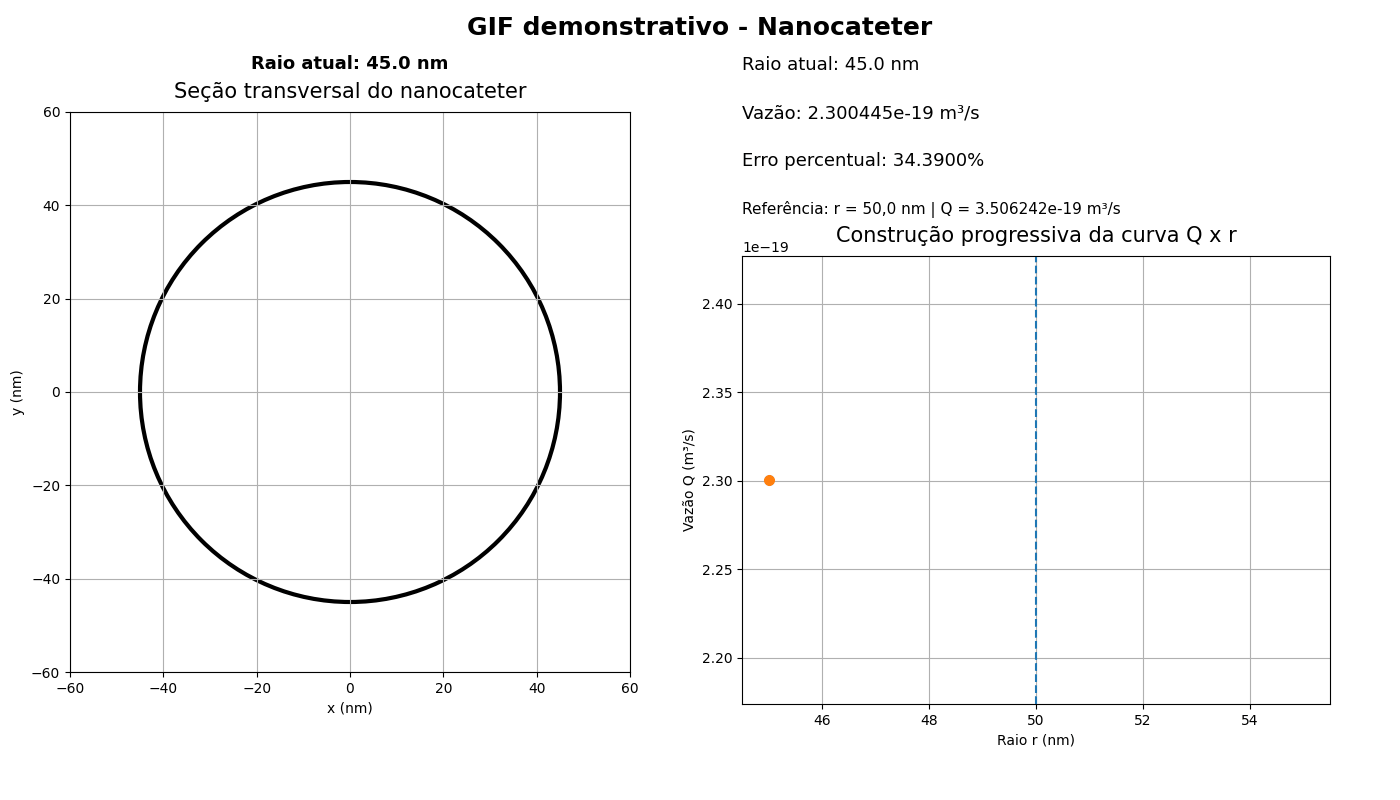

In [131]:
fig = plt.figure(figsize = (14, 8))

fig.suptitle(
    "GIF demonstrativo - Nanocateter",
    fontsize = 20,
    fontweight = "bold",
    y = 0.98
)

#grafico 1
ax1 = fig.add_axes([0.05, 0.12, 0.40, 0.78])

ax_info = fig.add_axes([0.53, 0.72, 0.42, 0.24])

#gráfico 2
ax2 = fig.add_axes([0.53, 0.12, 0.42, 0.56])

#função para desenhar os quadros
def atualizar(frame):
  raio_nm = raios_gif_nm[frame]
  raio_m = raios_gif_m[frame]

  Q_atual = vazoes_gif[frame]
  erro_atual = erro_gif[frame]

  ax1.clear()

  #gráfico 1
  circulo = plt.Circle(
      (0, 0),
      raio_nm,
      fill = False,
      linewidth = 3
  )

  ax1.add_patch(circulo)

  limite = 60

  ax1.set_xlim(-limite, limite)
  ax1.set_ylim(-limite, limite)

  ax1.set_aspect("equal")

  ax1.set_xlabel("x (nm)")
  ax1.set_ylabel("y (nm)")

  ax1.set_title("Seção transversal do nanocateter",
                fontsize = 15,
                pad = 10
                )

  ax1.grid(True)

  ax1.text(
      0.5,
      1.04,
      f"Raio atual: {raio_nm:.1f} nm\n",
      transform = ax1.transAxes,
      ha = "center",
      fontsize = 13,
      fontweight = "bold"
  )

  ax_info.clear()
  ax_info.axis("off")

  ax_info.text(
      0.0,
      0.80,
      f"Raio atual: {raio_nm:.1f} nm",
      fontsize = 13
  )

  ax_info.text(
      0.0,
      0.55,
      f"Vazão: {Q_atual:.6e} m³/s",
      fontsize = 13
  )

  ax_info.text(
      0.0,
      0.30,
      f"Erro percentual: {erro_atual:.4f}%",
      fontsize = 13
  )

  ax_info.text(
      0.0,
      0.05,
      f"Referência: r = 50,0 nm | Q = {Q_ref_gif:.6e} m³/s",
      fontsize = 11
  )

  #grafico 2

  ax2.clear()

  ax2.plot(raios_gif_nm[:frame + 1], vazoes_gif[:frame + 1], linewidth = 2)

  ax2.plot(raio_nm, Q_atual, marker = "o", markersize = 7)

  ax2.axvline(
      50,
      linestyle = "--",
      linewidth = 1.5
  )

  ax2.set_xlim(44.5, 55.5)

  ax2.set_xlabel("Raio r (nm)")
  ax2.set_ylabel("Vazão Q (m³/s)")

  ax2.set_title(
      "Construção progressiva da curva Q x r",
      fontsize = 15,
      pad = 10
      )

  ax2.grid(True)

  fig.suptitle(
      "GIF demonstrativo - Nanocateter",
      fontsize = 18,
      fontweight = "bold",
      y = 0.98
  )

animacao = FuncAnimation(
    fig,
    atualizar,
    frames = len(raios_gif_nm),
    interval = 120,
    repeat = True
)

nome_gif = "nanocateter.gif"

animacao.save(
    nome_gif,
    writer = PillowWriter(fps = 8)
)

plt.close(fig)

display(Image(filename = nome_gif))